# Visualización de mecanismos de atención en Transformers

En este notebook exploramos cómo los modelos basados en transformers utilizan el mecanismo de self-attention para modelar relaciones entre palabras en un texto.

En particular, analizaremos los pesos de atención que aprende el modelo **bert-base-uncased**. Estos pesos indican a qué tokens presta atención cada token al construir su representación contextualizada.


Esto nos permite observar qué patrones de atención aprende el modelo y cómo diferentes capas y cabezas capturan distintas relaciones entre palabras en la oración. Por ejemplo, algunas heads aprenden:

dependencias sintácticas

correferencias

relaciones locales

In [1]:
!pip -q install transformers torch matplotlib numpy

In [2]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
import matplotlib.pyplot as plt

Cargamos el modelo


In [ ]:
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
# eager: Usa la implementación estándar de atención en PyTorch, sin optimizaciones especiales.
# eager me permita acceder a los pesos de atención
model = AutoModel.from_pretrained(model_name,attn_implementation="eager")
# model.eval()

# Número de capas (layers)
num_layers = model.config.num_hidden_layers

# Número de heads de atención
num_heads = model.config.num_attention_heads

print(f"Número de capas: {num_layers}")
print(f"Número de heads: {num_heads}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


La siguiente función calcula y visualiza un mapa de atención (attention map) de un modelo transformer. Hace las siguientes tareas:+

- tokenizar un texto de entrada,

- obtener los pesos de atención del modelo,

- seleccionar una capa y una cabeza de atención (attention head),

- visualizar el mapa de atención mediante un heatmap.



In [ ]:
# 4) Función para visualizar atención
def plot_attention(tokenizer, model, text, layer=0, head=0):
    # Convierte el texto en tokens e IDs que el modelo puede procesar.
    inputs = tokenizer(text, return_tensors="pt")
    # Esto hace que el modelo devuelva también los pesos de atención.
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    if outputs.attentions is None:
        raise ValueError(
            "El modelo no devolvió attentions. "
            "Asegúrate de haber cargado el modelo con attn_implementation='eager'."
        )

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    # Es una matriz con los pesos de atención aprendidos en la primera capa, primera cabeza
    attention = outputs.attentions[layer][0, head].cpu().numpy()

    # quitar tokens especiales  [CLS], [SEP]
    keep_idx = [
        i for i, tok in enumerate(tokens)
        if tok not in tokenizer.all_special_tokens
    ]

    filtered_tokens = [tokens[i] for i in keep_idx]
    attention = attention[np.ix_(keep_idx, keep_idx)]

    plt.figure(figsize=(8, 6))
    plt.imshow(attention, aspect="auto")
    plt.xticks(range(len(filtered_tokens)), filtered_tokens, rotation=45, ha="right")
    plt.yticks(range(len(filtered_tokens)), filtered_tokens)
    plt.colorbar()
    plt.title(f"Attention map | layer={layer} head={head}")
    plt.tight_layout()
    plt.show()

    return filtered_tokens, attention

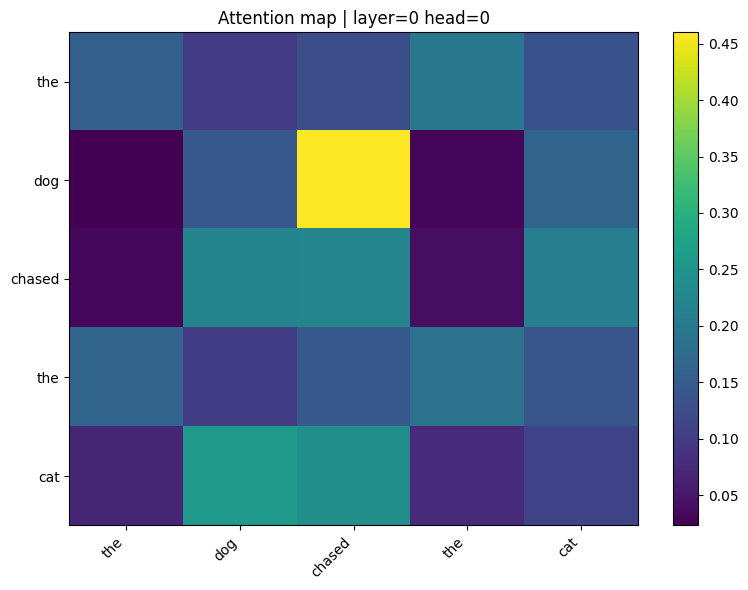

(['the', 'dog', 'chased', 'the', 'cat'],
 array([[0.15691005, 0.09967121, 0.12826099, 0.1976854 , 0.13273123],
        [0.02312413, 0.14403628, 0.46008438, 0.03032199, 0.16377427],
        [0.03243108, 0.22033839, 0.22269076, 0.03860721, 0.20987208],
        [0.16604114, 0.10329504, 0.14475346, 0.1868567 , 0.1405249 ],
        [0.07074466, 0.2598007 , 0.23938762, 0.07658073, 0.11063784]],
       dtype=float32))

In [ ]:
plot_attention(tokenizer, model, "The dog chased the cat")

La imagen es un mapa de atención para la oración: the dog chased the cat.

Es la atención que se aprende en la capa 0 y head 0.

- Filas → palabra que está “mirando”
- Columnas → palabras a las que presta atención
- Color más claro → más atención
- Color oscuro → poca atención

1) Fila dog: La celda más clara está en chased. ¿Qué significa? Dog presta mucha atención a chased. Esto tiene sentido porque dog es el sujeto y chased es el verbo.

**El modelo (en la head = 0) está capturando la relación sujeto → verbo.**

2) Fila cat: las celdas más claras están en dog y chased.
cat presta atención al verbo y al sujeto

Esto refleja la estructura: dog → chased → cat

3) Fila chased: el verbo presta atención a dog y a cat .
Esto es muy interesante porque el verbo necesita saber:
- quién hace la acción (dog = sujeto)
- sobre quién se realiza (cat = objeto)

4) Filas the: los determinantes suelen prestar atención al sustantivo que modifican. Aunque en esta cabeza concreta la señal no es tan fuerte.

Por tanto, esta cabeza de atención está capturando la estructura básica de la oración: dog (sujeto) → chased (verbo) → cat (objeto)



Veamos que captura esa head, para la oración **The cat chased the dog**.

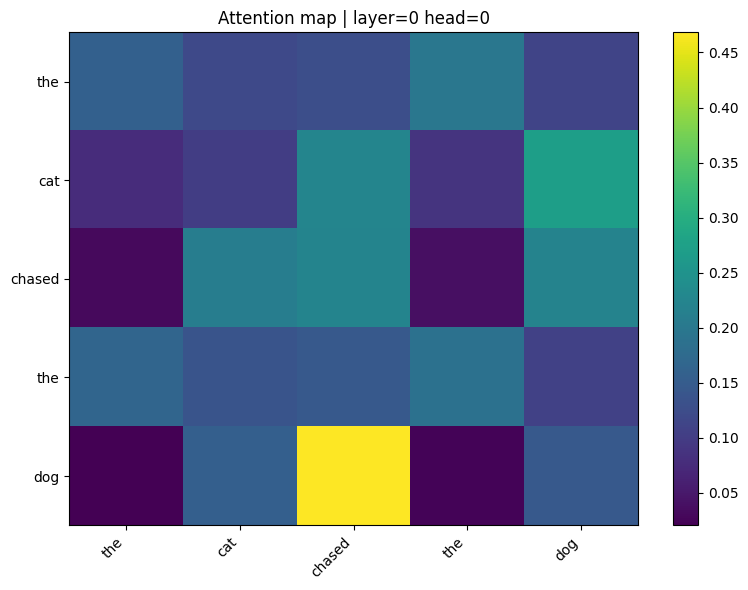

(['the', 'cat', 'chased', 'the', 'dog'],
 array([[0.15706809, 0.11972767, 0.12839016, 0.19788451, 0.11190169],
        [0.07707188, 0.10193855, 0.22468661, 0.08797438, 0.2714023 ],
        [0.032402  , 0.21034057, 0.22249109, 0.03857259, 0.2203808 ],
        [0.16601963, 0.13751173, 0.14473471, 0.1868325 , 0.10640611],
        [0.02056327, 0.15680166, 0.46825603, 0.02548018, 0.14522089]],
       dtype=float32))

In [ ]:
# 6) Más ejemplos
plot_attention(tokenizer, model, "The cat chased the dog", layer=0, head=0)


- dog → chased (muy fuerte). Esta head está capturando la relación objeto–verbo.
- cat → chased
cat también presta atención al verbo, reflejando la relación sujeto–verbo.

chased → cat y dog
El verbo presta atención a ambos sustantivos, porque son sus argumentos (quién realiza la acción y sobre quién).

the → sustantivo cercano
Los determinantes the atienden principalmente a los sustantivos que modifican.

Idea principal

Esta cabeza de atención está capturando la estructura básica de la oración: cat (sujeto) → chased (verbo) → dog (objeto)


El gráfico muestra los patrones de atención aprendidos por una cabeza (*head*) específica del modelo Transformer.

En BERT, las relaciones de **coreferencia** (como “it” → “animal”) suelen aparecer en capas intermedias o altas, no en las primeras. La capa 0, por ejemplo, tiende a capturar relaciones más locales, como determinantes, tokens vecinos o estructura superficial.

| Capas | Tipo de información                         |
|-------|--------------------------------------------|
| 0–3   | Relaciones locales (determinantes, vecinos) |
| 4–7   | Sintaxis (sujeto–verbo, verbo–objeto)       |
| 8–11  | Relaciones semánticas y coreferencia        |

Por ejemplo, algunas *attention heads* pueden aprender:

- **Relaciones sintácticas**: sujeto (perro) ↔ verbo (ladra), verbo (come) ↔ objeto (carne)  
- **Relaciones semánticas**: perro ↔ ladra, perro ↔ grande  
- **Coreferencia**: “Juan … él”  

Es decir, distintos *heads* pueden especializarse en diferentes tipos de relaciones lingüísticas (sintácticas, semánticas, etc.). Sin embargo, muchos *heads* son redundantes o contribuyen poco de forma individual.

Por tanto, el significado no reside en un único *head*, sino que **emerge del conjunto de heads y capas del modelo**.

En general, las capas siguen una progresión aproximada:

> léxico → sintaxis → semántica






## Ejercicio: Qué aprenden las capas profundas de BERT


El objetivo es comprender cómo las capas más profundas del modelo capturan información contextual y semántica, y cómo diferentes attention heads pueden especializarse en distintos tipos de relaciones lingüísticas.


Utilizando la oración:

"The animal did not cross the street because it was tired"

Recorre las capas superiores del modelo (de la capa 6 a la 11) y todas sus cabezas de atención, y visualiza los mapas de atención correspondientes.

- Analiza los patrones observados y responde:
- ¿Qué palabras reciben mayor atención?
- ¿Se observan relaciones semánticas (por ejemplo, entre "it" y "animal")?
- ¿Hay heads que capturen relaciones sintácticas claras?
- ¿Existen diferencias entre capas en cuanto al tipo de información capturada?


The trophy does not fit in the suitcase because it is too big


## Ejercicio: Análisis de ambigüedad y atención en BERT

En este ejercicio vas a analizar cómo un modelo Transformer maneja ambigüedades semánticas mediante los mecanismos de atención.

Se utilizarán las siguientes dos oraciones:

“The trophy does not fit in the suitcase because it is too small”

“The trophy does not fit in the suitcase because it is too big”

Ambas oraciones contienen una ambigüedad en el pronombre “it”:

En la primera frase, “it” suele referirse a “the suitcase”

En la segunda frase, “it” suele referirse a “the trophy”

👉 Resolver esto requiere comprensión semántica, no solo sintaxis.

Responde a las siguientes preguntas:
- ¿Cambia el patrón de atención entre las dos oraciones?
- ¿A qué palabra atiende el token “it” en cada oración?
- ¿Existen heads que conecten explícitamente: “it” → “trophy”, “it” → “suitcase”?
- ¿En qué capas se observa más claramente la resolución de la ambigüedad?
